<a href="https://colab.research.google.com/github/GabGP/SP1-AI/blob/main/labs/SP1_Laboratory_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Gabriel Garcia
17001171

## Preparations

In [ ]:
# ----- Libraries ----- #

# This is the main Library that allows us to work with Neural Networks
import tensorflow as tf

# For graph plotting
import matplotlib.pyplot as plt
from tensorflow.math import confusion_matrix

# For dataset manipulation
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

# For visualizing more complex graphs
import seaborn as sns

# Global constant for training acceleration
AUTOTUNE = tf.data.AUTOTUNE

# Regression


## 1) Dataset Preparations

In [ ]:
'''
The dataset you are going to use is the following:
https://archive.ics.uci.edu/ml/datasets/Auto+MPG
'''

# Retrieve the dataset
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
auto_mpg = fetch_ucirepo(id=9)

In [ ]:
# Loading Dataset and have a glimpse about it
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight', 'Acceleration', 'Model_Year', 'Origin']

raw_dataset = auto_mpg.data.targets.join(auto_mpg.data.features)
raw_dataset = raw_dataset.iloc[:, [0, 2, 1, 3, 4, 5, 6, 7]]
raw_dataset = raw_dataset.to_csv('auto_mpg.data', header=False, index=False)
raw_dataset = pd.read_csv('auto_mpg.data', names=column_names,
                      na_values = "?", comment='\t',
                      sep=",", skipinitialspace=True)
raw_dataset

# Hint: Make sure to check out the files first! And pay attention how data is separated

# Brief Statistical Summary of the dataset
raw_dataset.describe()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model_Year,Origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


In [ ]:
# Lets check columns
raw_dataset.columns

Index(['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
       'Acceleration', 'Model_Year', 'Origin'],
      dtype='object')

In [ ]:
# Summary of the dataset
raw_dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model_Year,Origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


In [ ]:
# Returns a form of (# rows, # columns)
raw_dataset.shape

(398, 8)

In [ ]:
# Lets make a copy
new_dataset = raw_dataset.copy()

# Lets check for null values
print(new_dataset.isna().sum())

# Dropping null rows
new_dataset = new_dataset.dropna()

# Checking new dataset
new_dataset.head()

MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model_Year      0
Origin          0
dtype: int64


,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model_Year,Origin
0,18.0,8,307.0,130.0,3504,12.0,70,1
1,15.0,8,350.0,165.0,3693,11.5,70,1
2,18.0,8,318.0,150.0,3436,11.0,70,1
3,16.0,8,304.0,150.0,3433,12.0,70,1
4,17.0,8,302.0,140.0,3449,10.5,70,1


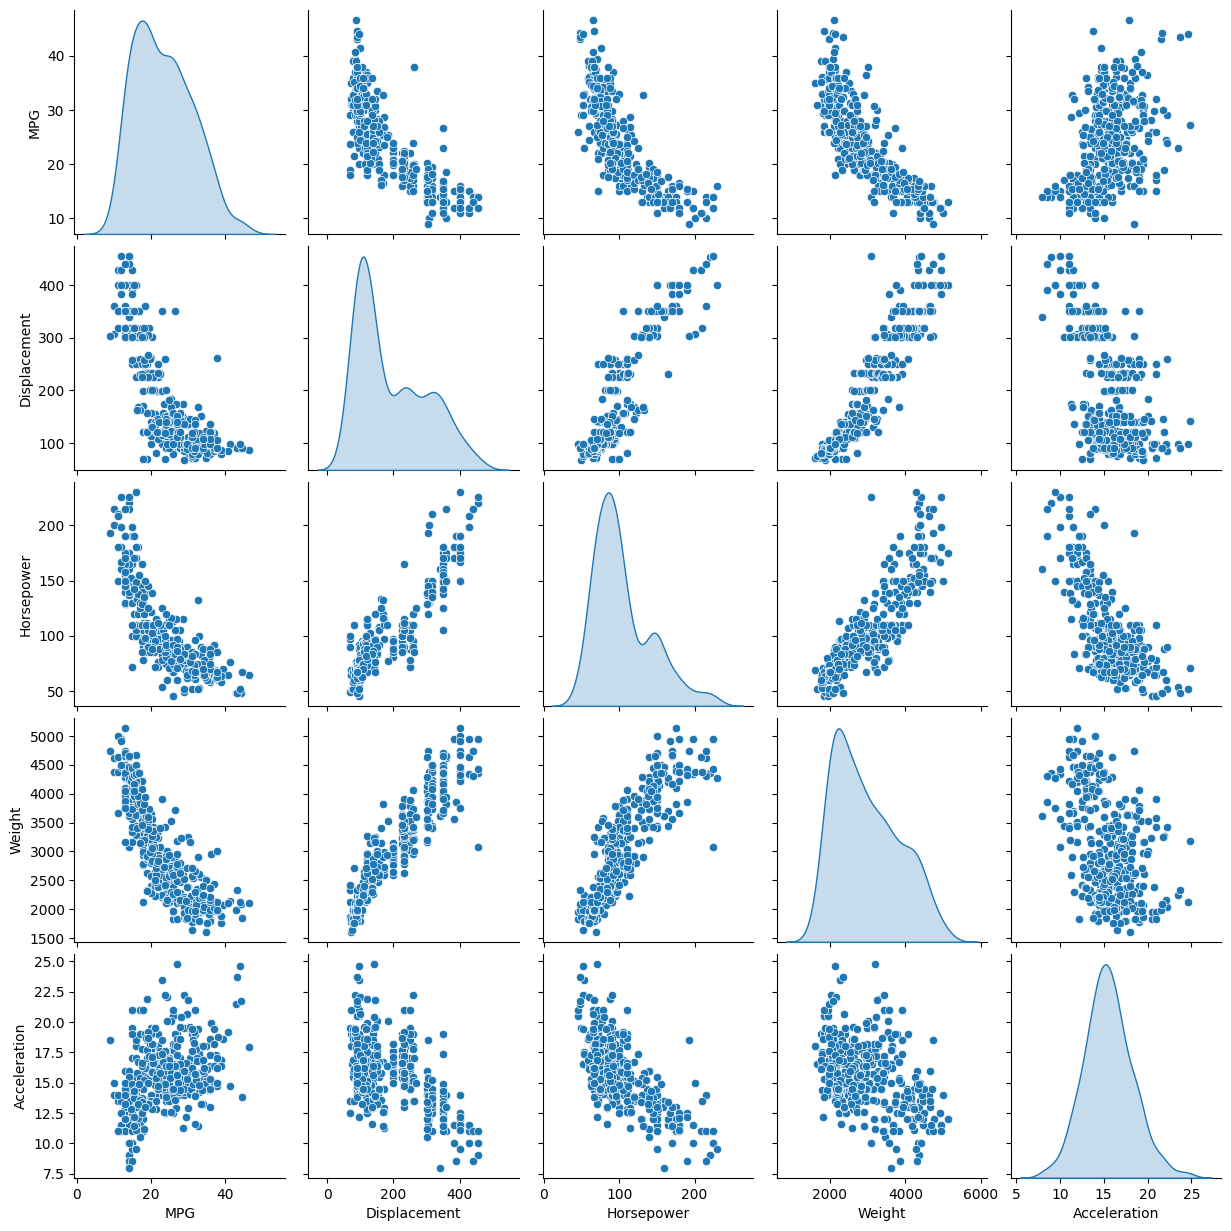

In [ ]:
# Lets visualize the data

sns.pairplot(new_dataset[['MPG','Displacement','Horsepower',
                'Weight', 'Acceleration']], diag_kind="kde")
# Hint: Choose 5 NUMERICAL variables

## 2) NN for a simple Regression

In [ ]:
# Splitting dataset into training and testing
train, test = train_test_split(new_dataset, test_size=0.2)

# Separating both sets into dependent and independent variables

# Hint: Make sure you select only numerical variables.
# Feel free to choose the number of independent variables
# you want and the dependent variable is MPG
independent_variables = ['Cylinders', 'Displacement', 'Horsepower', 'Weight',
                         'Acceleration', 'Model_Year', 'Origin']
dependent_variables = ['MPG']

train_set = train[independent_variables]
train_target = train[dependent_variables]

test_set = test[independent_variables]
test_target = test[dependent_variables]

In [ ]:
train_set.shape

(313, 7)

In [ ]:
# Build your model!
model = tf.keras.models.Sequential([
  tf.keras.layers.InputLayer(input_shape=(7,)),
  tf.keras.layers.Dense(units=64, activation='relu'),
  tf.keras.layers.Dense(units=64, activation='relu'),
  tf.keras.layers.Dense(units=1),
  ])

# Now compile the model!
model.compile(
    loss='mse',
    optimizer='adam',
    metrics=[tf.keras.metrics.RootMeanSquaredError()]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
# Now lets train the model!
# Hint: Feel free to change a few parameters
model.fit(train_set,
          train_target,
          epochs=200,
          batch_size=32,
          validation_split=0.2
        )

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - loss: 2487.7725 - root_mean_squared_error: 49.8776 - val_loss: 120.2315 - val_root_mean_squared_error: 10.9650
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 696.6246 - root_mean_squared_error: 26.3936 - val_loss: 220.2728 - val_root_mean_squared_error: 14.8416
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 374.5558 - root_mean_squared_error: 19.3534 - val_loss: 169.2516 - val_root_mean_squared_error: 13.0097
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 212.0388 - root_mean_squared_error: 14.5616 - val_loss: 209.7038 - val_root_mean_squared_error: 14.4812
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 131.5692 - root_mean_squared_error: 11.4704 - val_loss: 139.7532 - val_root_mean_squared_error: 11.8217
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 109.6957 - root_mean_squared_error: 10.4736 - val_loss: 110.9943 - val_root_mean_squared_error: 10.5354
Epoch 7/200
8/8 ━━━━━━━━━━━

In [ ]:
# Evaluate your model
model.evaluate(x=test_set, y=test_target, batch_size=32)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 19.1598 - root_mean_squared_error: 4.3772


[19.159847259521484, 4.377196311950684]

# Classification

## 1) Dataset Preparations

In [ ]:
'''
The dataset you are going to use is the following:
https://archive.ics.uci.edu/ml/datasets/Ecoli
'''

# Retrieve the dataset
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
ecoli = fetch_ucirepo(id=39)

In [ ]:
# Loading Dataset and have a glimpse about it
column_names = ['name','MCG','GVH','LIP', 'CHG', 'AAC', 'ALM1', 'ALM2', 'class']

raw_dataset = ecoli.data.original
raw_dataset = raw_dataset.to_csv('ecoli.data', header=False, index=False)
raw_dataset = pd.read_csv('ecoli.data', names=column_names,
                      na_values = "?", comment='\t',
                      sep=",", skipinitialspace=True)
raw_dataset
# Hint: Make sure to check out the files first! And pay attention how data is separated

# Brief Statistical Summary of the dataset
raw_dataset.describe()

,MCG,GVH,LIP,CHG,AAC,ALM1,ALM2
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000
mean,0.500060,0.500000,0.495476,0.501488,0.500030,0.500179,0.499732
std,0.194634,0.148157,0.088495,0.027277,0.122376,0.215751,0.209411
min,0.000000,0.160000,0.480000,0.500000,0.000000,0.030000,0.000000
25%,0.340000,0.400000,0.480000,0.500000,0.420000,0.330000,0.350000
50%,0.500000,0.470000,0.480000,0.500000,0.495000,0.455000,0.430000
75%,0.662500,0.570000,0.480000,0.500000,0.570000,0.710000,0.710000
max,0.890000,1.000000,1.000000,1.000000,0.880000,1.000000,0.990000


In [ ]:
# Lets check columns
raw_dataset.columns

Index(['name', 'MCG', 'GVH', 'LIP', 'CHG', 'AAC', 'ALM1', 'ALM2', 'class'], dtype='object')

In [ ]:
# Summary of the dataset
raw_dataset.head()

,name,MCG,GVH,LIP,CHG,AAC,ALM1,ALM2,class
0,AAT_ECOLI,0.49,0.29,0.48,0.5,0.56,0.24,0.35,cp
1,ACEA_ECOLI,0.07,0.40,0.48,0.5,0.54,0.35,0.44,cp
2,ACEK_ECOLI,0.56,0.40,0.48,0.5,0.49,0.37,0.46,cp
3,ACKA_ECOLI,0.59,0.49,0.48,0.5,0.52,0.45,0.36,cp
4,ADI_ECOLI,0.23,0.32,0.48,0.5,0.55,0.25,0.35,cp


In [ ]:
# Returns a form of (# rows, # columns)
raw_dataset.shape

(336, 9)

In [ ]:
# Lets make a copy
new_dataset = raw_dataset.copy()

# Lets check for null values
# df.dropna()
print(new_dataset.isna().sum())

# Dropping null rows
new_dataset = new_dataset.dropna()

# Checking new dataset
new_dataset.head()

name     0
MCG      0
GVH      0
LIP      0
CHG      0
AAC      0
ALM1     0
ALM2     0
class    0
dtype: int64


,name,MCG,GVH,LIP,CHG,AAC,ALM1,ALM2,class
0,AAT_ECOLI,0.49,0.29,0.48,0.5,0.56,0.24,0.35,cp
1,ACEA_ECOLI,0.07,0.40,0.48,0.5,0.54,0.35,0.44,cp
2,ACEK_ECOLI,0.56,0.40,0.48,0.5,0.49,0.37,0.46,cp
3,ACKA_ECOLI,0.59,0.49,0.48,0.5,0.52,0.45,0.36,cp
4,ADI_ECOLI,0.23,0.32,0.48,0.5,0.55,0.25,0.35,cp


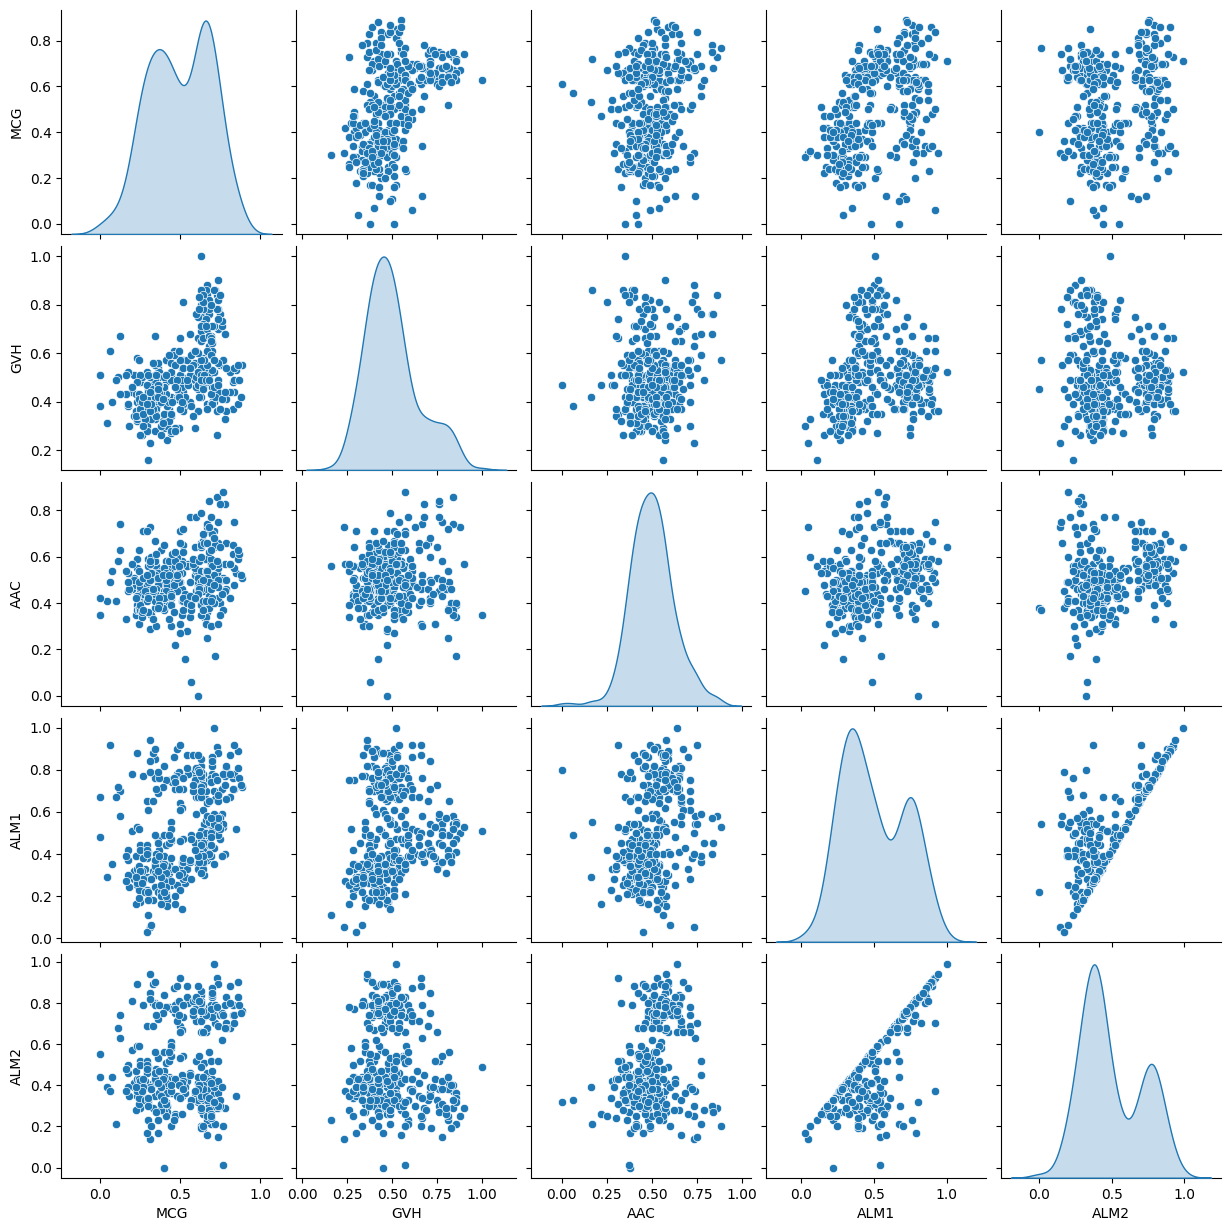

In [ ]:
# Lets visualize the data

sns.pairplot(new_dataset[['MCG','GVH','AAC',
                'ALM1', 'ALM2']], diag_kind="kde")
# Hint: Choose 5 NUMERICAL variables

In [ ]:
# Enconding the target before splitting the dataset
new_dataset['class'] = pd.factorize(new_dataset['class'])[0]

# Splitting dataset into training and testing
train, test = train_test_split(new_dataset, test_size=0.2)

# Separating both sets into dependent and independent variables

# Hint: Make sure you select only numerical variables.
# Feel free to choose the number you want and the dependent variables is 'class'
independent_variables = ['MCG','GVH','LIP', 'CHG', 'AAC', 'ALM1', 'ALM2']
dependent_variables = ['class']

train_set = train[independent_variables]
train_target = train[dependent_variables]

test_set = test[independent_variables]
test_target = test[dependent_variables]

In [ ]:
train_target, test_target

(     class
 149      1
 254      4
 249      4
 208      1
 243      4
 ..     ...
 176      1
 106      0
 88       0
 247      4
 11       0
 
 [268 rows x 1 columns],
      class
 274      5
 307      7
 132      0
 289      7
 98       0
 ..     ...
 113      0
 282      6
 9        0
 133      0
 295      7
 
 [68 rows x 1 columns])

In [ ]:
# NNs can't understand strings, we have to ENCODE them! (more next class)
# train_target = pd.factorize(train_target['class'])[0]
# test_target = pd.factorize(test_target['class'])[0]
# Encoding is done before splitting the dataset, else the values are mapped to
# a different string

## 2) NN for Classification

In [ ]:
train_set.shape

(268, 7)

In [ ]:
print(np.unique_counts(train_target))
print(np.unique_counts(test_target))

UniqueCountsResult(values=array([0, 1, 2, 3, 4, 5, 6, 7]), counts=array([108,  66,   2,   1,  30,  15,   4,  42]))
UniqueCountsResult(values=array([0, 1, 3, 4, 5, 6, 7]), counts=array([35, 11,  1,  5,  5,  1, 10]))


In [ ]:
# Build your model!
model = tf.keras.models.Sequential([
  tf.keras.layers.InputLayer(input_shape=(7,)),
  tf.keras.layers.Dense(units=16, activation='relu'),
  tf.keras.layers.Dense(units=16, activation='relu'),
  tf.keras.layers.Dense(units=8, activation='softmax')
  ])
# Hint: Is this a binary or multiclassification problem? A: Multiclassification

# Now compile the model!
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              optimizer='adam',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
# Now lets train the model!
model.fit(train_set,
          train_target,
          epochs=200,
          batch_size = 16,
          validation_split=0.2
        )

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.3972 - loss: 1.9911 - val_accuracy: 0.3519 - val_loss: 1.9618
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4112 - loss: 1.9020 - val_accuracy: 0.3704 - val_loss: 1.8751
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4112 - loss: 1.8221 - val_accuracy: 0.3704 - val_loss: 1.7923
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4112 - loss: 1.7536 - val_accuracy: 0.3704 - val_loss: 1.7148
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4112 - loss: 1.6987 - val_accuracy: 0.3704 - val_loss: 1.6505
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4112 - loss: 1.6556 - val_accuracy: 0.3704 - val_loss: 1.5973
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4112 - loss: 1.6237 - val_accuracy: 0.3704 - val_loss: 1.5582
Epoch 8/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4112 - loss: 1.6018 - val_accuracy: 0.3704 - 

In [ ]:
# Evaluate your model
model.evaluate(x=test_set, y=test_target, batch_size=16)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8971 - loss: 0.4671 


[0.4670807123184204, 0.8970588445663452]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


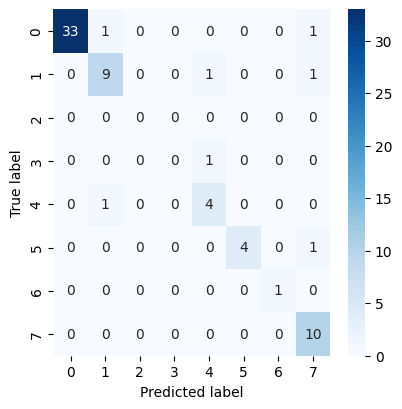

In [ ]:
# Function that plots confusion matrix
def plot_confusion_matrix(labels, predictions):
  figure = plt.figure(figsize=(4, 4))
  sns.heatmap(confusion_matrix(labels=labels, predictions=predictions), annot=True,cmap=plt.cm.Blues)
  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')
  plt.show()

# Confusion Matrix
predictions = list(map(lambda x: np.argmax(x), model.predict(test_set)))

plot_confusion_matrix(labels=test_target, predictions=predictions)

# Conclusions

After you are done with both previous models, make 3 different models for the regression problem and 3 for the classification problem.

Annotate the results in a Text Cell below this one (only the metrics shown in the evaluation phase) and then write a conclusion which model was the best for each problem.

1. Regression

- 3 neurons (2 relu@64, 1 sigmoid@32) + output relu@1 - Batch: 32 - [12ms/step - loss: 75.1256 - root_mean_squared_error: 8.6675]
- 4 neurons (relu@64) + output relu@1 - Batch: 32 - [12ms/step - loss: 554.6915 - root_mean_squared_error: 23.5519]
- BEST: 2 neurons (relu@64) + output linear - Batch: 32 - [43ms/step - loss: 8.3659 - root_mean_squared_error: 2.8924]

The best model for regression is clearly the third one, because the loss and rmse is consider to be within range of a healthy model. Also, this one is the simpler model. Interstingly the time per step is considerably slower than the other models, but considering it yields better results, it is still acceptable.

2. Classification

- 2 neurons (relu:@64) + output softmax@8 - Batch: 32 - [13ms/step - accuracy: 0.8824 - loss: 0.4457]
- 3 neurons (2 relu@64, 1 sigmoid@32) + output softmax@8 - Batch: 32 - [15ms/step - accuracy: 0.8676 - loss: 0.4512]
- BEST: 2 neurons (relu:@16) + output softmax@8 - Batch: 16 - [8ms/step - accuracy: 0.8971 - loss: 0.4671]

The best model for classification is the third one, because while the accuracy and loss is marginally better, than the others. The time per step is faster and the model itself is simpler and lighter than the others, for example they have a smaller batch and units, which saves resources. However, it should be consider that the accuracy and loss will vary from run to run, but within an acceptable range.

# READ ME

When you are finished with your laboratory, remember to share it. Make the URL public for Galileo.edu domain or for everyone.
Also, remember to hit Ctrl+S to save your progress.